# Paths

In [1]:
DATA_PATH = "/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/" 

ERA5_DIR = DATA_PATH+"unziped/ERA5_Cropped/"  # Folder with both pressure and single level files
WRF_DIR = DATA_PATH+"unziped/WRF_2km/"

ERA5_INTERPOLATED_DIR = DATA_PATH+"ERA5_interpolated_447/"
ERA5_WRF_COMBINED_DIR = DATA_PATH+ "ERA5_WRF_combined_447/"
ERA5_WRF_COMBINED_CONCATENATED_DIR = DATA_PATH + "ERA5_WRF_combined_concatenated_432/"

STAT_DIR = DATA_PATH + "stats_432/"

In [2]:
OUTPUT_DIR = "/app/outputs/"

REGRESSION_CHECKPOINTS_DIR = OUTPUT_DIR + "checkpoints_regression"
REGRESSION_CHECKPOINT_INDEX = 535008

DIFFUSION_CHECKPOINTS_DIR = OUTPUT_DIR + "checkpoints_diffusion"
DIFFUSION_CHECKPOINT_INDEX = 265008

In [3]:
import os
#ls -l /app/outputs/checkpoints_regression
#ls -l /app/outputs/checkpoints_diffusion

print(f"regression checkpoints at {REGRESSION_CHECKPOINTS_DIR}")
regression_entries = sorted(os.scandir(REGRESSION_CHECKPOINTS_DIR), key=lambda e: e.name)
for entry in regression_entries:
    print(f"{entry.stat().st_mode:o} {entry.stat().st_size} {entry.name}")

print()
print(f"diffusion checkpoints at {DIFFUSION_CHECKPOINTS_DIR}")
diffusion_entries = sorted(os.scandir(DIFFUSION_CHECKPOINTS_DIR), key=lambda e: e.name)
for entry in diffusion_entries:
    print(f"{entry.stat().st_mode:o} {entry.stat().st_size} {entry.name}")

regression checkpoints at /app/outputs/checkpoints_regression
100644 316610560 UNet.0.490000.mdlus
100644 316610560 UNet.0.495008.mdlus
100644 316610560 UNet.0.500000.mdlus
100644 316610560 UNet.0.505008.mdlus
100644 316610560 UNet.0.510000.mdlus
100644 316610560 UNet.0.515008.mdlus
100644 316610560 UNet.0.520000.mdlus
100644 316610560 UNet.0.525008.mdlus
100644 316610560 UNet.0.530000.mdlus
100644 316610560 UNet.0.535008.mdlus
100644 627380085 checkpoint.0.490000.pt
100644 627380085 checkpoint.0.495008.pt
100644 627380085 checkpoint.0.500000.pt
100644 627380085 checkpoint.0.505008.pt
100644 627380085 checkpoint.0.510000.pt
100644 627380085 checkpoint.0.515008.pt
100644 627380085 checkpoint.0.520000.pt
100644 627380085 checkpoint.0.525008.pt
100644 627380085 checkpoint.0.530000.pt
100644 627380085 checkpoint.0.535008.pt

diffusion checkpoints at /app/outputs/checkpoints_diffusion
100644 316620800 EDMPrecondSuperResolution.0.220000.mdlus
100644 316620800 EDMPrecondSuperResolution.0.2250

# Load regression model

In [4]:
import os
import torch
from physicsnemo.models.diffusion.unet import UNet
from physicsnemo.launch.utils.checkpoint import load_checkpoint

In [5]:
# Model arguments for regression (should match your training config)
regression_model_args = {
    "N_grid_channels": 4,
    "gridtype": "sinusoidal",
    "embedding_type": "zero",
    "model_channels": 128,
    "channel_mult": [1, 2, 2, 2, 2],
    "attn_resolutions": [28],
    "model_type": "SongUNetPosEmbd",
}

# Create regression model
regression_model = UNet(
    img_in_channels=20,  # 16 variables + 4 grid channels
    img_out_channels=2,  # U10, V10
    img_resolution=432,
    **regression_model_args,
)

print(f"Regression model created with:")
print(f"  - Input channels: 20 (16 variables + 4 grid)")
print(f"  - Output channels: 2 (U10, V10)")
print(f"  - Resolution: 432x432")
print(f"  - Model channels: {regression_model_args['model_channels']}")
print(f"  - Channel multipliers: {regression_model_args['channel_mult']}")

Regression model created with:
  - Input channels: 20 (16 variables + 4 grid)
  - Output channels: 2 (U10, V10)
  - Resolution: 432x432
  - Model channels: 128
  - Channel multipliers: [1, 2, 2, 2, 2]


In [6]:
# Load regression checkpoint
regression_checkpoint_index = None  # Use latest checkpoint
regression_model_loaded = False

try:
    regression_epoch = load_checkpoint(
        path=REGRESSION_CHECKPOINTS_DIR,
        models=regression_model,
        epoch=REGRESSION_CHECKPOINT_INDEX,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    regression_model.eval()
    regression_model_loaded = True
    print(f"✓ Regression model loaded successfully from epoch {regression_epoch}")
    print(f"✓ Model set to evaluation mode")
    
    # Move to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    regression_model = regression_model.to(device)
    print(f"✓ Model moved to device: {device}")
    
except Exception as e:
    print(f"✗ Failed to load regression model: {e}")
    print(f"✗ Will use simulation mode instead")
    regression_model = None

`DistributedManager` not initialized already. Initializing now, but this might lead to unexpected errors
/app/physicsnemo/distributed/manager.py:415: UserWarning: Could not initialize using ENV, SLURM or OPENMPI methods. Assuming this is a single process job
  warn(


✓ Regression model loaded successfully from epoch 535008
✓ Model set to evaluation mode
✓ Model moved to device: cuda


## Inspect regression model

In [7]:
if regression_model_loaded:
    print("=== Regression Model Architecture ===")
    print(f"Model type: {type(regression_model).__name__}")
    print(f"Model device: {next(regression_model.parameters()).device}")
    print(f"Model dtype: {next(regression_model.parameters()).dtype}")
    
    # Count parameters
    total_params = sum(p.numel() for p in regression_model.parameters())
    trainable_params = sum(p.numel() for p in regression_model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Model memory usage
    if torch.cuda.is_available():
        model_memory = sum(p.numel() * p.element_size() for p in regression_model.parameters()) / (1024**3)
        print(f"Model memory usage: {model_memory:.2f} GB")
else:
    print("No regression model loaded to inspect")

=== Regression Model Architecture ===
Model type: UNet
Model device: cuda:0
Model dtype: torch.float32
Total parameters: 78,355,586
Trainable parameters: 78,355,586
Model memory usage: 0.29 GB


## Test regression model

### Test on dummy data

In [ ]:
if regression_model_loaded:
    print("=== Testing Regression Model on Dummy Data ===")
    
    # Create test inputs with correct dimensions
    batch_size = 2  # Test with small batch
    height = width = 432
    
    # Test input dimensions
    print(f"Creating dummy test tensors:")
    print(f"  - HR input (zeros): {batch_size} x 2 x {height} x {width}")
    print(f"  - LR input (16 vars): {batch_size} x 16 x {height} x {width}")
    print(f"  - Grid channels (added internally): 4 channels")
    
    # Create test tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    hr_input = torch.zeros(batch_size, 2, height, width, device=device)  # Zero input for regression
    lr_input = torch.randn(batch_size, 16, height, width, device=device)  # Random LR variables
    
    # Test forward pass
    try:
        with torch.no_grad():
            start_time = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
            end_time = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
            
            if torch.cuda.is_available():
                start_time.record()
            
            # Forward pass
            output = regression_model(hr_input, lr_input)
            
            if torch.cuda.is_available():
                end_time.record()
                torch.cuda.synchronize()
                inference_time = start_time.elapsed_time(end_time)
                print(f"✓ Forward pass successful! Inference time: {inference_time:.2f} ms")
            else:
                print(f"✓ Forward pass successful!")
            
            print(f"✓ Output shape: {output.shape}")
            print(f"✓ Output dtype: {output.dtype}")
            print(f"✓ Output device: {output.device}")
            print(f"✓ Output statistics:")
            print(f"    - Mean: {output.mean().item():.6f}")
            print(f"    - Std: {output.std().item():.6f}")
            print(f"    - Min: {output.min().item():.6f}")
            print(f"    - Max: {output.max().item():.6f}")
            
            # Check for NaN or Inf
            if torch.isnan(output).any():
                print(f"⚠ Warning: Output contains NaN values")
            if torch.isinf(output).any():
                print(f"⚠ Warning: Output contains infinite values")
            
            print(f"✓ Dummy data test completed successfully!")
            
    except Exception as e:
        print(f"✗ Forward pass failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("No regression model loaded to test")

### Test on real data

In [ ]:
# Load real test data
import json
import xarray as xr
import numpy as np

print("=== Loading Real Test Data ===")
data_path = ERA5_WRF_COMBINED_CONCATENATED_DIR + "2024-04-30_2024-05-30_21.nc"
stats_path = STAT_DIR + "stat.json"

if os.path.exists(data_path) and os.path.exists(stats_path):
    print(f"Loading test data from: {data_path}")
    print(f"Loading statistics from: {stats_path}")
    
    # Load data
    input_group = xr.open_dataset(data_path, group="input")
    output_group = xr.open_dataset(data_path, group="output")
    input_data = input_group.isel(sample=100)
    output_data = output_group.isel(sample=100)
    
    with open(stats_path) as f:
        stats = json.load(f)
    
    print(f"✓ Data loaded successfully")
    print(f"  - Input variables: {list(input_data.data_vars)}")
    print(f"  - Output variables: {list(output_data.data_vars)}")
    print(f"  - Input shape: {input_data.dims}")
    print(f"  - Output shape: {output_data.dims}")
    
    # Check variable ranges
    print(f"\n✓ Input variable statistics:")
    for var in list(input_data.data_vars)[:5]:  # Show first 5 variables
        data = input_data[var].values
        print(f"  - {var}: min={data.min():.3f}, max={data.max():.3f}, mean={data.mean():.3f}")
    
    print(f"\n✓ Output variable statistics:")
    for var in list(output_data.data_vars):
        data = output_data[var].values
        print(f"  - {var}: min={data.min():.3f}, max={data.max():.3f}, mean={data.mean():.3f}")
        
    real_data_loaded = True
    
else:
    print(f"✗ Test data or statistics not found")
    print(f"  - Data path exists: {os.path.exists(data_path)}")
    print(f"  - Stats path exists: {os.path.exists(stats_path)}")
    real_data_loaded = False

In [ ]:
if regression_model_loaded and real_data_loaded:
    print("=== Testing Regression Model on Real Data ===")
    
    # Normalization functions
    def normalize_input(data, var_name, stats):
        mean = stats["input"][var_name]["mean"]
        std = stats["input"][var_name]["std"]
        return (data - mean) / std
    
    def denormalize_output(data, var_name, stats):
        mean = stats["output"][var_name]["mean"]
        std = stats["output"][var_name]["std"]
        return (data * std) + mean
    
    # Prepare real input variables (16 total)
    selected_vars = [
        't_850', 't_500', 'z_850', 'z_500',  # 4 variables
        'u_850', 'u_500', 'v_850', 'v_500',  # +4 = 8
        'u10', 'v10', 't2m', 'd2m',          # +4 = 12
        "skt", "sp", "tcwv", "tp"            # +4 = 16
    ]
    
    print(f"Preparing input variables: {len(selected_vars)} variables")
    
    # Stack and normalize input variables
    input_stack = []
    for var in selected_vars:
        var_data = input_data[var].values
        var_norm = normalize_input(var_data, var, stats)
        input_stack.append(var_norm)
        print(f"  - {var}: normalized range [{var_norm.min():.3f}, {var_norm.max():.3f}]")
    
    input_array = np.stack(input_stack, axis=0)  # Shape: (16, 432, 432)
    input_tensor = torch.from_numpy(input_array).float().unsqueeze(0)  # (1, 16, 432, 432)
    
    print(f"\n✓ Input tensor shape: {input_tensor.shape}")
    print(f"✓ Input tensor range: [{input_tensor.min():.3f}, {input_tensor.max():.3f}]")
    
    # Run regression on real data
    try:
        with torch.no_grad():
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            input_tensor = input_tensor.to(device)
            
            # Zero input for regression (as per training)
            zero_input = torch.zeros(1, 2, 432, 432, device=device)
            
            # Forward pass
            start_time = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
            end_time = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
            
            if torch.cuda.is_available():
                start_time.record()
            
            # Run regression
            output_regression = regression_model(zero_input, input_tensor)
            
            if torch.cuda.is_available():
                end_time.record()
                torch.cuda.synchronize()
                inference_time = start_time.elapsed_time(end_time)
                print(f"\n✓ Real data inference time: {inference_time:.2f} ms")
            
            print(f"✓ Regression output shape: {output_regression.shape}")
            print(f"✓ Regression output range: [{output_regression.min():.3f}, {output_regression.max():.3f}]")
            
            # Denormalize predictions
            u10_pred = output_regression[0, 0].cpu().numpy()
            v10_pred = output_regression[0, 1].cpu().numpy()
            
            u10_denorm = denormalize_output(u10_pred, "U10", stats)
            v10_denorm = denormalize_output(v10_pred, "V10", stats)
            
            # Get ground truth
            u10_true = output_data["U10"].values
            v10_true = output_data["V10"].values
            
            # Compute basic metrics
            u10_mae = np.mean(np.abs(u10_denorm - u10_true))
            v10_mae = np.mean(np.abs(v10_denorm - v10_true))
            
            u10_rmse = np.sqrt(np.mean((u10_denorm - u10_true)**2))
            v10_rmse = np.sqrt(np.mean((v10_denorm - v10_true)**2))
            
            # R² computation
            u10_ss_tot = np.sum((u10_true - np.mean(u10_true))**2)
            u10_ss_res = np.sum((u10_true - u10_denorm)**2)
            u10_r2 = 1 - (u10_ss_res / u10_ss_tot)
            
            v10_ss_tot = np.sum((v10_true - np.mean(v10_true))**2)
            v10_ss_res = np.sum((v10_true - v10_denorm)**2)
            v10_r2 = 1 - (v10_ss_res / v10_ss_tot)
            
            print(f"\n=== Regression Performance Metrics ===")
            print(f"U10 (Wind Component):")
            print(f"  - MAE: {u10_mae:.4f}")
            print(f"  - RMSE: {u10_rmse:.4f}")
            print(f"  - R²: {u10_r2:.4f}")
            print(f"  - Pred mean: {u10_denorm.mean():.4f}, True mean: {u10_true.mean():.4f}")
            print(f"  - Pred std: {u10_denorm.std():.4f}, True std: {u10_true.std():.4f}")
            
            print(f"\nV10 (Wind Component):")
            print(f"  - MAE: {v10_mae:.4f}")
            print(f"  - RMSE: {v10_rmse:.4f}")
            print(f"  - R²: {v10_r2:.4f}")
            print(f"  - Pred mean: {v10_denorm.mean():.4f}, True mean: {v10_true.mean():.4f}")
            print(f"  - Pred std: {v10_denorm.std():.4f}, True std: {v10_true.std():.4f}")
            
            print(f"\n✓ Real data test completed successfully!")
            regression_real_test_passed = True
            
    except Exception as e:
        print(f"\n✗ Real data test failed: {e}")
        import traceback
        traceback.print_exc()
        regression_real_test_passed = False
        
else:
    print("Cannot test on real data - model or data not loaded")
    regression_real_test_passed = False

In [ ]:
# Optional: Visualize a small region of the regression results
if regression_model_loaded and real_data_loaded and 'output_regression' in locals():
    import matplotlib.pyplot as plt
    
    print("=== Quick Visualization ===")
    
    # Select a small region for visualization
    y_start, y_end = 100, 200
    x_start, x_end = 100, 200
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # U10 comparison
    im1 = axes[0, 0].imshow(u10_denorm[y_start:y_end, x_start:x_end], cmap='coolwarm')
    axes[0, 0].set_title('U10 Prediction')
    axes[0, 0].set_xlabel('X')
    axes[0, 0].set_ylabel('Y')
    plt.colorbar(im1, ax=axes[0, 0])
    
    im2 = axes[0, 1].imshow(u10_true[y_start:y_end, x_start:x_end], cmap='coolwarm')
    axes[0, 1].set_title('U10 Ground Truth')
    axes[0, 1].set_xlabel('X')
    axes[0, 1].set_ylabel('Y')
    plt.colorbar(im2, ax=axes[0, 1])
    
    im3 = axes[0, 2].imshow((u10_denorm - u10_true)[y_start:y_end, x_start:x_end], cmap='RdBu_r')
    axes[0, 2].set_title('U10 Residual (Pred - True)')
    axes[0, 2].set_xlabel('X')
    axes[0, 2].set_ylabel('Y')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # V10 comparison
    im4 = axes[1, 0].imshow(v10_denorm[y_start:y_end, x_start:x_end], cmap='coolwarm')
    axes[1, 0].set_title('V10 Prediction')
    axes[1, 0].set_xlabel('X')
    axes[1, 0].set_ylabel('Y')
    plt.colorbar(im4, ax=axes[1, 0])
    
    im5 = axes[1, 1].imshow(v10_true[y_start:y_end, x_start:x_end], cmap='coolwarm')
    axes[1, 1].set_title('V10 Ground Truth')
    axes[1, 1].set_xlabel('X')
    axes[1, 1].set_ylabel('Y')
    plt.colorbar(im5, ax=axes[1, 1])
    
    im6 = axes[1, 2].imshow((v10_denorm - v10_true)[y_start:y_end, x_start:x_end], cmap='RdBu_r')
    axes[1, 2].set_title('V10 Residual (Pred - True)')
    axes[1, 2].set_xlabel('X')
    axes[1, 2].set_ylabel('Y')
    plt.colorbar(im6, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.suptitle(f'Regression Results - Region [{y_start}:{y_end}, {x_start}:{x_end}]', y=1.02)
    plt.show()
    
    print(f"✓ Visualization completed for region [{y_start}:{y_end}, {x_start}:{x_end}]")
else:
    print("Skipping visualization - no regression results available")

## Summary of regression testing

In [ ]:
print("=== Regression Model Test Summary ===")
print(f"Model loaded: {'✓' if regression_model_loaded else '✗'}")
print(f"Dummy data test: {'✓' if regression_model_loaded else '✗'}")
print(f"Real data loaded: {'✓' if real_data_loaded else '✗'}")
print(f"Real data test: {'✓' if regression_real_test_passed else '✗'}")

if regression_model_loaded:
    print(f"\nModel details:")
    print(f"  - Architecture: UNet")
    print(f"  - Input channels: 20 (16 variables + 4 grid)")
    print(f"  - Output channels: 2 (U10, V10)")
    print(f"  - Resolution: 432x432")
    print(f"  - Parameters: {sum(p.numel() for p in regression_model.parameters()):,}")

if 'u10_r2' in locals() and 'v10_r2' in locals():
    print(f"\nPerformance on real data:")
    print(f"  - U10 R²: {u10_r2:.4f}")
    print(f"  - V10 R²: {v10_r2:.4f}")
    print(f"  - Average R²: {(u10_r2 + v10_r2)/2:.4f}")

if regression_model_loaded and real_data_loaded and regression_real_test_passed:
    print(f"\n🎉 All regression tests passed! Ready to proceed with diffusion.")
elif not regression_model_loaded:
    print(f"\n⚠️  Regression model not loaded. Will use simulation mode for diffusion.")
else:
    print(f"\n⚠️  Some tests failed. Check the outputs above for details.")

## Compare with simulation

In [9]:
# Test both regression model and simulation for comparison
print("=== Comparing Regression Model vs Simulation ===")

# Load a sample for testing
import json
import xarray as xr
import numpy as np

# Load test data
data_path = ERA5_WRF_COMBINED_CONCATENATED_DIR + "2024-04-30_2024-05-30_21.nc"
stats_path = STAT_DIR + "stat.json"

if os.path.exists(data_path) and os.path.exists(stats_path):
    print(f"Loading test data from: {data_path}")
    print(f"Loading statistics from: {stats_path}")
    
    # Load data
    input_group = xr.open_dataset(data_path, group="input")
    output_group = xr.open_dataset(data_path, group="output")
    input_data = input_group.isel(sample=100)
    output_data = output_group.isel(sample=100)
    
    with open(stats_path) as f:
        stats = json.load(f)
    
    print(f"✓ Data loaded successfully")
    print(f"  - Input variables: {list(input_data.data_vars)}")
    print(f"  - Output variables: {list(output_data.data_vars)}")
    print(f"  - Input shape: {input_data.dims}")
    print(f"  - Output shape: {output_data.dims}")
else:
    print(f"✗ Test data or statistics not found")
    print(f"  - Data path exists: {os.path.exists(data_path)}")
    print(f"  - Stats path exists: {os.path.exists(stats_path)}")

=== Comparing Regression Model vs Simulation ===
Loading test data from: /mnt/storage/younes.abid/physicsnemo/data/custom_data_2/ERA5_WRF_combined_concatenated_432/2024-04-30_2024-05-30_21.nc
Loading statistics from: /mnt/storage/younes.abid/physicsnemo/data/custom_data_2/stats_432/stat.json
✓ Data loaded successfully
  - Input variables: ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sst', 'sp', 'tcwv', 'tp']
  - Output variables: ['T2', 'U10', 'V10', 'rain_rate', 'SST', 'TSK', 'Q2', 'PSFC']
  - Input shape: FrozenMappingWarningOnValuesAccess({'y_lr': 432, 'x_lr': 432})
  - Output shape: FrozenMappingWarningOnValuesAccess({'y_hr': 432, 'x_hr': 432})


# Load diffusion model

## Load model

In [2]:
ls -lh /app/outputs/checkpoints_diffusion/

total 8.8G
-rw-r--r-- 1 root root 302M Oct  9 05:26 EDMPrecondSuperResolution.0.220000.mdlus
-rw-r--r-- 1 root root 302M Oct  9 05:55 EDMPrecondSuperResolution.0.225008.mdlus
-rw-r--r-- 1 root root 302M Oct  9 06:37 EDMPrecondSuperResolution.0.230000.mdlus
-rw-r--r-- 1 root root 302M Oct  9 07:05 EDMPrecondSuperResolution.0.235008.mdlus
-rw-r--r-- 1 root root 302M Oct  9 07:33 EDMPrecondSuperResolution.0.240000.mdlus
-rw-r--r-- 1 root root 302M Oct  9 08:01 EDMPrecondSuperResolution.0.245008.mdlus
-rw-r--r-- 1 root root 302M Oct  9 08:30 EDMPrecondSuperResolution.0.250000.mdlus
-rw-r--r-- 1 root root 302M Oct  9 08:58 EDMPrecondSuperResolution.0.255008.mdlus
-rw-r--r-- 1 root root 302M Oct  9 09:26 EDMPrecondSuperResolution.0.260000.mdlus
-rw-r--r-- 1 root root 302M Oct  9 10:08 EDMPrecondSuperResolution.0.265008.mdlus
-rw-r--r-- 1 root root 599M Oct  9 05:26 checkpoint.0.220000.pt
-rw-r--r-- 1 root root 599M Oct  9 05:55 checkpoint.0.225008.pt
-rw-r--r-- 1 root root 599M Oct  9 06:37 

In [5]:
import os
import torch
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution
from physicsnemo.launch.utils.checkpoint import load_checkpoint

# Paths configuration
checkpoint_dir = "/app/outputs/checkpoints_diffusion"  # Directory where model checkpoints are stored
checkpoint_index = 265008  # Specific checkpoint number to load (from training logs)

# Model Initialization Parameters
# These arguments come from the training config YAML file
model_args = {
    # Number of additional grid channels for positional/conditional information
    # From model_args.N_grid_channels in training config
    "N_grid_channels": 4,
    
    # Type of positional embedding grid (sinusoidal, learned, etc.)
    # From model_args.gridtype in training config
    "gridtype": "sinusoidal",
    
    # Type of embedding for diffusion timesteps/noise levels
    # From model_args.embedding_type in training config
    "embedding_type": "zero",
    
    # Base number of channels in the model (scaled by channel_mult)
    # From model_args.model_channels in training config
    "model_channels": 128, #64,
    
    # Channel multipliers for different resolution levels
    # [1, 2, 2] means: 64, 128, 128 channels at different resolutions
    # From model_args.channel_mult in training config
    "channel_mult": [1, 2, 2, 2, 2], #[1, 2, 2],
    
    # Resolutions at which to apply attention layers
    # From model_args.attn_resolutions in training config
    "attn_resolutions": [28], #[16],
    
    # Minimum noise level for diffusion process
    # Default value for EDM framework
    "sigma_min": 0.0,
    
    # Maximum noise level for diffusion process
    # Default value for EDM framework
    "sigma_max": 1.0,
    
    # Data standard deviation scaling factor
    # Default value for EDM framework
    "sigma_data": 0.5,
    
    # Type of UNet architecture being used
    # From model_args.model_type in training config
    "model_type": "SongUNetPosEmbd",
}

# Create the EDM Super-Resolution model
model = EDMPrecondSuperResolution(
    # Input image resolution (448x448)
    # Should match the resolution used during training
    img_resolution=432,
    
    # Number of input channels:
    # - 14: From input_variables in dataset config (t_850, t_500, z_850, etc.)
    # - 4: From N_grid_channels (positional/conditional information)
    # - 4: Likely from hr_mean_conditioning (2 output vars × 2 for mean/std)
    # Total = 22 channels (14 + 4 + 4)
    img_in_channels=22,
    
    # Number of output channels:
    # - 2: Matches output_variables in dataset config (U10, V10)
    img_out_channels=2,
    
    # Pass all other model configuration parameters
    **model_args,
)

# Load the pre-trained checkpoint
epoch = load_checkpoint(
    path=checkpoint_dir,  # Directory containing checkpoints
    models=model,        # Model to load weights into
    epoch=checkpoint_index,  # Checkpoint number to load
    device="cuda",       # Load onto GPU (use "cpu" if no GPU available)
    # strict=False       # Uncomment to ignore mismatched keys (not recommended)
)

print(f"Model loaded successfully from epoch {epoch}")

# Set the model to evaluation mode (important for inference)
model.eval()

Model loaded successfully from epoch 265008


EDMPrecondSuperResolution(
  (model): SongUNetPosEmbd(
    (enc): ModuleDict(
      (432x432_conv): Conv2d()
      (432x432_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (432x432_block1): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (432x432_block2): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (432x432_block3): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (216x216_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
 

## Inspect model

In [6]:
import inspect
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution

# Print the forward method signature
print(inspect.signature(EDMPrecondSuperResolution.forward))

# Or for more details:
print(inspect.getsource(EDMPrecondSuperResolution.forward))

(self, x: torch.Tensor, img_lr: torch.Tensor, sigma: torch.Tensor, force_fp32: bool = False, **model_kwargs: dict) -> torch.Tensor
    def forward(
        self,
        x: torch.Tensor,
        img_lr: torch.Tensor,
        sigma: torch.Tensor,
        force_fp32: bool = False,
        **model_kwargs: dict,
    ) -> torch.Tensor:
        """
        Forward pass of the EDMPrecondSuperResolution model wrapper.

        This method applies the EDM preconditioning to compute the denoised image
        from a noisy high-resolution image and low-resolution conditioning image.

        Parameters
        ----------
        x : torch.Tensor
            Noisy high-resolution image of shape (B, C_hr, H, W). The number of
            channels `C_hr` should be equal to `img_out_channels`.
        img_lr : torch.Tensor
            Low-resolution conditioning image of shape (B, C_lr, H, W). The number
            of channels `C_lr` should be equal to `img_in_channels`.
        sigma : torch.Tensor

In [8]:
import torch

# Correct channel dimensions accounting for positional embeddings
batch_size = 1
main_channels = 18 # 16+2
hr_channels = 2  # U10/V10 output
height = width = 432

# Create properly sized dummy tensors
dummy_x = torch.randn(batch_size, hr_channels, height, width)  # High-res (2 channels)
dummy_img_lr = torch.randn(batch_size, main_channels, height, width)  # Low-res (18 channels)
sigma = torch.tensor([1.0])  # Noise level

# Run inference
with torch.no_grad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dummy_x = dummy_x.to(device)
    dummy_img_lr = dummy_img_lr.to(device)
    model = model.to(device)
    sigma = sigma.to(device)
    
    try:
        output = model(x=dummy_x, img_lr=dummy_img_lr, sigma=sigma)
        print("Success! Output shape:", output.shape)
    except Exception as e:
        print("Failed:", str(e))

/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


Success! Output shape: torch.Size([1, 2, 432, 432])


## Test diffusion

In [12]:
import xarray as xr
import torch
import numpy as np
import json
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

def get_data(data_path, sample_idx):
    # Open the dataset
    input_group = xr.open_dataset(data_path, group="input")
    output_group = xr.open_dataset(data_path, group="output")
    
    # Select the first sample for inference
    input_data = input_group.isel(sample=sample_idx)
    output_data = output_group.isel(sample=sample_idx)
    return input_data, output_data
    
def simulate_regression(output_data, noise_std=0.1, jitter_std=0.05, kernel_size=5):
    """
    Simulate regression by smoothing the data, adding noise, and applying jitter.

    Parameters:
    ----------
    output_data : dict
        Dictionary containing regression output data with keys like "U10" and "V10".
    noise_std : float, optional
        Standard deviation of the Gaussian noise to add, by default 0.1.
    jitter_std : float, optional
        Standard deviation of the jitter multiplier, by default 0.05.
    kernel_size : int, optional
        Size of the Gaussian smoothing kernel, by default 5.

    Returns:
    -------
    torch.Tensor
        Simulated regression data of shape (1, 2, H, W).
    """
    # Extract data and convert to PyTorch tensors
    u10 = torch.tensor(output_data["U10"].values, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W)
    v10 = torch.tensor(output_data["V10"].values, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W)

    # Concatenate along the channel dimension
    data = torch.cat((u10, v10), dim=1)  # Shape: (1, 2, H, W)

    # Apply Gaussian smoothing
    kernel = torch.ones((2, 1, kernel_size, kernel_size), dtype=torch.float32) / (kernel_size ** 2)  # Create 2 filters
    kernel = kernel.to(data.device)
    smoothed_data = F.conv2d(data, kernel, padding=kernel_size // 2, groups=2)  # Shape: (1, 2, H, W)

    # Add Gaussian noise
    noise = torch.randn_like(smoothed_data) * noise_std
    noisy_data = smoothed_data + noise

    # Apply jitter (pixel-wise random multiplier)
    jitter = 1 + torch.randn_like(noisy_data) * jitter_std
    simulated_data = noisy_data * jitter

    return simulated_data

    
# 2. Normalization functions
def normalize(data, var_name, stats):
    mean = stats["input"][var_name]["mean"]
    std = stats["input"][var_name]["std"]
    return (data - mean) / std

def denormalize(data, var_name, stats):
    mean = stats["output"][var_name]["mean"]
    std = stats["output"][var_name]["std"]
    return (data * std) + mean

def diffuse(model, input_data, stats, output_regression, iteration):

    # 3. Prepare input variables (all 18 total channels)
    selected_vars = [
        't_850', 't_500', 'z_850', 'z_500',  # 4 variables
        'u_850', 'u_500', 'v_850', 'v_500',  # +4 = 8
        'u10', 'v10', 't2m', 'd2m',          # +4 = 12
        "skt", "sp", "tcwv", "tp"            # +4 = 16
    ]

    # Stack and normalize input variables
    input_stack = []
    for var in selected_vars:
        var_data = input_data[var].values
        var_norm = normalize(var_data, var, stats)
        input_stack.append(var_norm)

    input_array = np.stack(input_stack, axis=0)  # Shape: (16, 440, 440)
    input_tensor = torch.from_numpy(input_array).float().unsqueeze(0)  # (1, 16, 440, 440)

    # 4. Prepare grid channels (4 channels as per config)
    # grid_channels = torch.zeros(1, 4, 440, 440)  # Batch of 4 grid channels
    
    # 5. Prepare conditioning (2 channels - means of U10/V10 only)
    conditioning = torch.zeros(1, 2, 432, 432)
    conditioning[:, 0] = stats["output"]["U10"]["mean"]  # U10 mean
    conditioning[:, 1] = stats["output"]["V10"]["mean"]  # V10 mean

    # 6. Combine all inputs (16 vars + 2 conditioning = 18 channels) + 4 grid are not added 
    # The model will add 6 positional channels internally (18 + 6 = 24)
    # low_res_input = torch.cat([input_tensor, grid_channels, conditioning], dim=1)
    low_res_input = torch.cat([input_tensor, conditioning], dim=1)
    
    # 8. Run inference
    with torch.no_grad():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        output_regression = output_regression.to(device)
        low_res_input = low_res_input.to(device)
        model = model.to(device)
        
        # Prepare noise level (sigma)
        sigma = torch.tensor([1.0], device=device)

        output_diffusion = model(x=output_regression, img_lr=low_res_input, sigma=sigma)
        print(1)
        if iteration>1:
            for i in range(iteration-1):
                print(i+2)
                output_diffusion =  model(x=output_diffusion, img_lr=low_res_input, sigma=sigma)
    return output_diffusion

def post_process(output_diffuse):
    # 9. Process output_diffuse (U10 and V10)
    u10_pred = output_diffuse[0, 0]  # First output_diffuse channel
    v10_pred = output_diffuse[0, 1]  # Second output_diffuse channel
    
    u10_denorm = denormalize(u10_pred, "U10", stats)
    v10_denorm = denormalize(v10_pred, "V10", stats)
    return u10_denorm, v10_denorm
    
def plot_results_xarray(output_regression, output_diffuse, output_data, stats):
    """
    Plot results using xarray with a structured dataset containing 'type' dimension.
    Includes residuals for regression and diffusion.
    """
    # Post-process predictions
    u10_diffuse, v10_diffuse = post_process(output_diffuse)
    u10_regression = output_regression[0, 0, :, :].cpu().numpy()  # Extract U10 from regression
    v10_regression = output_regression[0, 1, :, :].cpu().numpy()  # Extract V10 from regression
    
    # Get ground truth
    u10_true = output_data["U10"].values
    v10_true = output_data["V10"].values

    # Calculate residuals
    u10_residual_regression = u10_regression - u10_true
    v10_residual_regression = v10_regression - v10_true
    u10_residual_diffusion = u10_diffuse - u10_true
    v10_residual_diffusion = v10_diffuse - v10_true

    # Print comparison
    print("U10 Prediction vs Ground Truth:")
    print(f"Diffuse Pred mean: {u10_diffuse.mean():.4f}, True mean: {u10_true.mean():.4f}")
    print(f"Diffuse Pred std: {u10_diffuse.std():.4f}, True std: {u10_true.std():.4f}")
    print(f"Regression Pred mean: {u10_regression.mean():.4f}")
    print(f"Regression Pred std: {u10_regression.std():.4f}")
    
    print("\nV10 Prediction vs Ground Truth:")
    print(f"Diffuse Pred mean: {v10_diffuse.mean():.4f}, True mean: {v10_true.mean():.4f}")
    print(f"Diffuse Pred std: {v10_diffuse.std():.4f}, True std: {v10_true.std():.4f}")
    print(f"Regression Pred mean: {v10_regression.mean():.4f}")
    print(f"Regression Pred std: {v10_regression.std():.4f}")
    
    # Get spatial dimensions
    y_dim, x_dim = u10_diffuse.shape
    
    # Create datasets with 'type' dimension
    # Dataset for U10
    ds_u10 = xr.Dataset({
        'U10': (['type', 'y', 'x'], [u10_regression, u10_diffuse, u10_true]),
        'Residual U10': (['type', 'y', 'x'], [u10_residual_regression, u10_residual_diffusion, np.zeros_like(u10_true)])
    }, coords={
        'type': ['output_regression', 'output_diffusion', 'ground_truth'],
        'y': range(y_dim),
        'x': range(x_dim)
    })
    
    # Dataset for V10
    ds_v10 = xr.Dataset({
        'V10': (['type', 'y', 'x'], [v10_regression, v10_diffuse, v10_true]),
        'Residual V10': (['type', 'y', 'x'], [v10_residual_regression, v10_residual_diffusion, np.zeros_like(v10_true)])
    }, coords={
        'type': ['output_regression', 'output_diffusion', 'ground_truth'],
        'y': range(y_dim),
        'x': range(x_dim)
    })
    
    # Plot U10 dataset
    print("\n=== U10 Wind Component ===") 
    ds_u10.U10.plot(
        col='type',  # Facet by prediction type
        col_wrap=3,
        cmap='coolwarm',
        robust=True,
        figsize=(15, 5),
    )
    plt.suptitle('U10 Wind Component - Regression vs Diffusion vs Ground Truth', y=1.02)
    plt.show()
    
    # # Plot Residual U10
    # print("\n=== Residual U10 ===")
    # ds_u10['Residual U10'].plot(
    #     col='type',
    #     col_wrap=3,
    #     cmap='coolwarm',
    #     robust=True,
    #     figsize=(15, 5),
    # )
    # plt.suptitle('Residual U10 - Regression vs Diffusion', y=1.02)
    # plt.show()
    
    # Plot V10 dataset
    print("\n=== V10 Wind Component ===")
    ds_v10.V10.plot(
        col='type',  # Facet by prediction type
        col_wrap=3,
        cmap='coolwarm',
        robust=True,
        figsize=(15, 5),
    )
    plt.suptitle('V10 Wind Component - Regression vs Diffusion vs Ground Truth', y=1.02)
    plt.show()

    # Plot Residual V10
    # print("\n=== Residual V10 ===")
    # ds_v10['Residual V10'].plot(
    #     col='type',
    #     col_wrap=3,
    #     cmap='coolwarm',
    #     robust=True,
    #     figsize=(15, 5),
    # )
    # plt.suptitle('Residual V10 - Regression vs Diffusion', y=1.02)
    # plt.show()

    # Return datasets for further analysis
    #return ds_u10, ds_v10
    

/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


1
U10 Prediction vs Ground Truth:
Diffuse Pred mean: 1.7577, True mean: 1.7200
Diffuse Pred std: 3.1754, True std: 2.8809
Regression Pred mean: 1.7146
Regression Pred std: 2.8194

V10 Prediction vs Ground Truth:
Diffuse Pred mean: -4.2113, True mean: -2.9457
Diffuse Pred std: 3.0288, True std: 2.5157
Regression Pred mean: -2.9313
Regression Pred std: 2.4558

=== U10 Wind Component ===


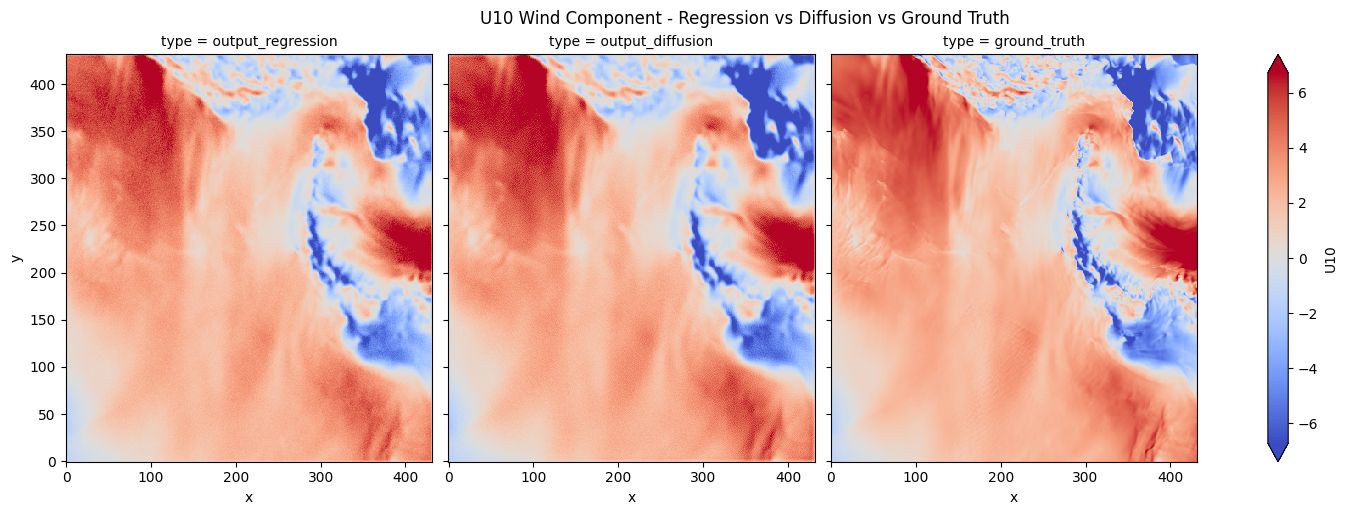


=== V10 Wind Component ===


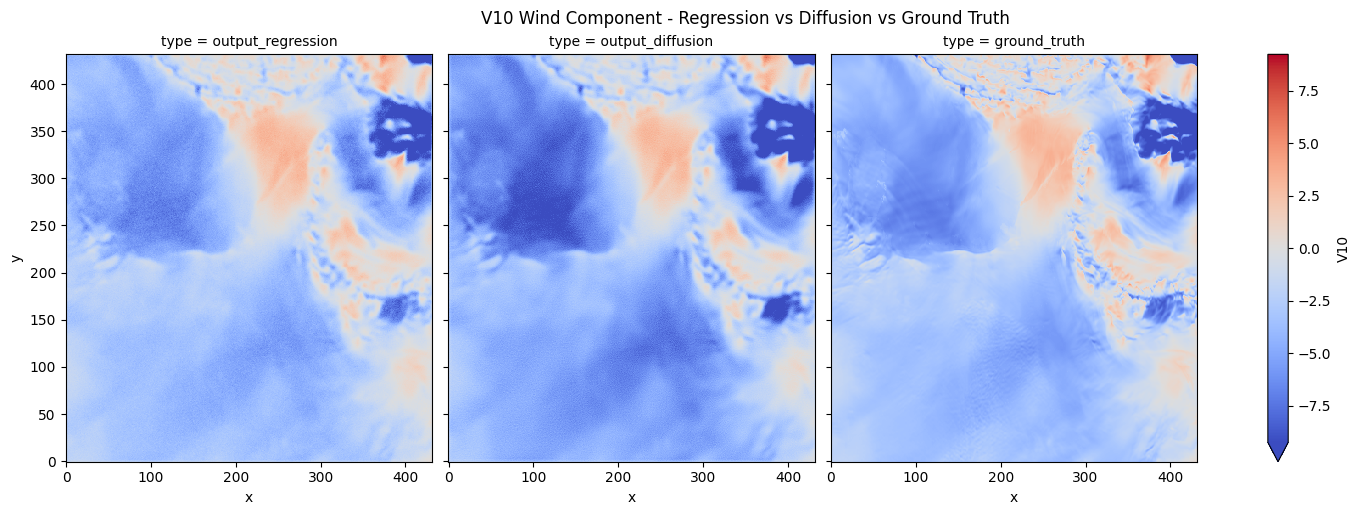

In [13]:
# 1. Load and prepare input data
data_path = ERA5_WRF_COMBINED_CONCATENATED_DIR + "2024-04-30_2024-05-30_21.nc"
stats_path = STAT_DIR + "stat.json"

input_data, output_data = get_data(data_path, sample_idx = 100)

with open(stats_path) as f:
    stats = json.load(f)

# 7. Prepare high-res input (2 channels of zeros as initial guess)
#output_regression = torch.zeros(1, 2, 440, 440)  # For U10/V10 output this came from regression
output_regression = simulate_regression(output_data)

output_diffuse = diffuse(model, input_data, stats, output_regression, iteration=1)
    
output_diffuse = output_diffuse.cpu().numpy()

plot_results_xarray(output_regression, output_diffuse, output_data, stats)


U10 Prediction vs Ground Truth:
Diffuse Pred mean: 1.7577, True mean: 1.7200
Diffuse Pred std: 3.1754, True std: 2.8809
Regression Pred mean: 1.7146
Regression Pred std: 2.8194

V10 Prediction vs Ground Truth:
Diffuse Pred mean: -4.2113, True mean: -2.9457
Diffuse Pred std: 3.0288, True std: 2.5157
Regression Pred mean: -2.9313
Regression Pred std: 2.4558

=== U10 Wind Component ===


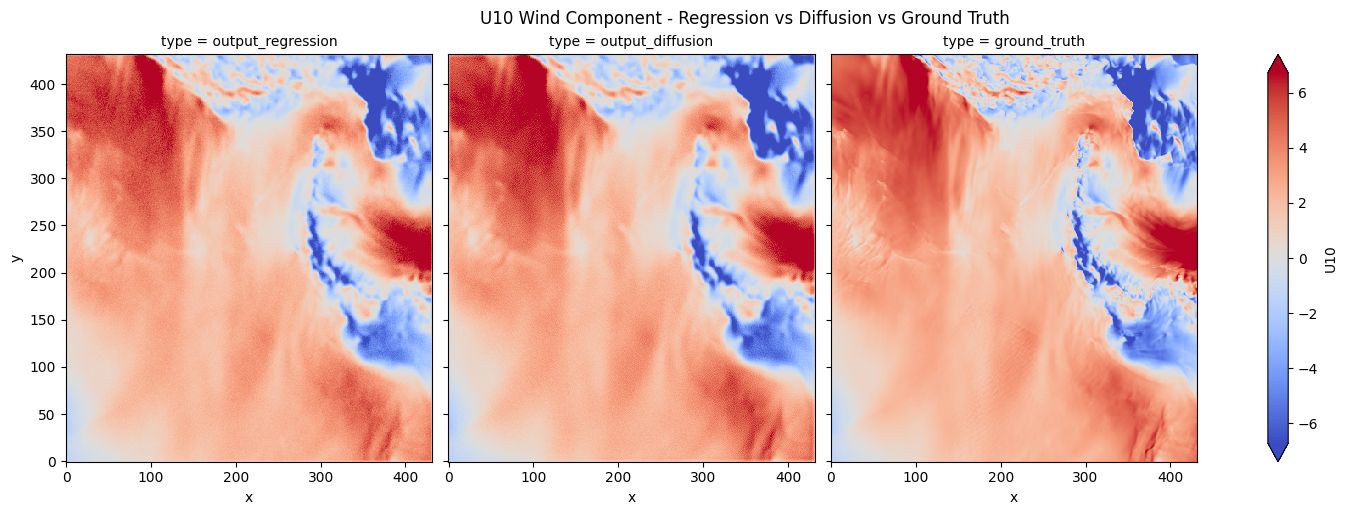


=== V10 Wind Component ===


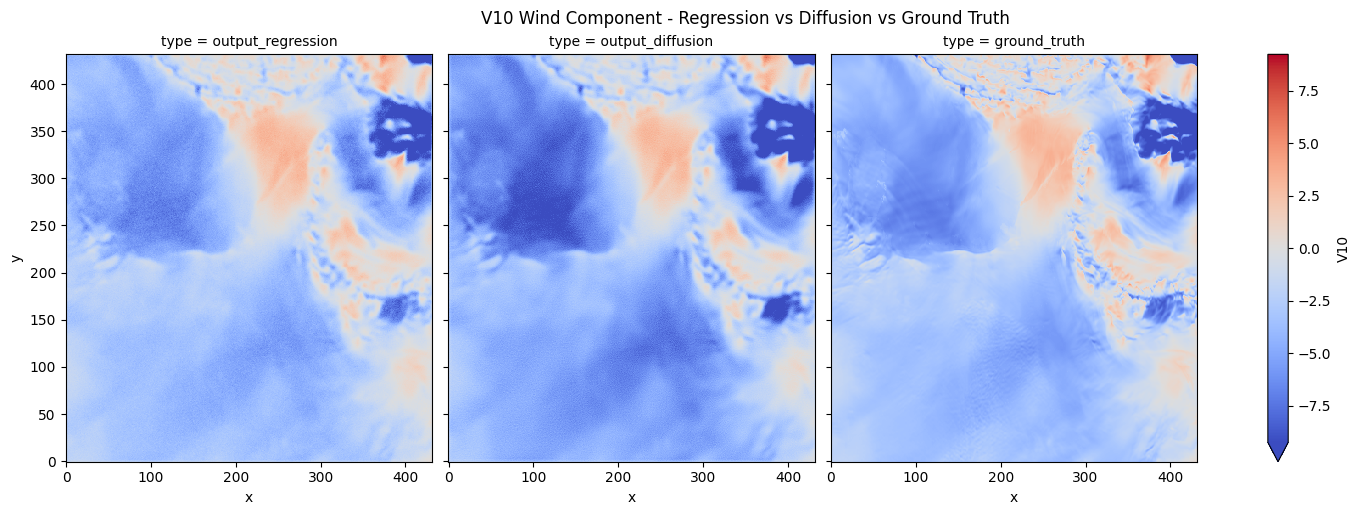

In [16]:
plot_results_xarray(output_regression, output_diffuse, output_data, stats)